In [1]:
%load_ext autoreload
%autoreload 2

# Project: Image segmentation

## Goal

The goal in this project is to create a tissue segmentation method, based on the techniques you have seen so far. This method should generalize well to different images. We will be using the same images as in the segmentation exercises.

Similar to project 1, your assignment is to investigate of what method or combination of methods is most suitable for doing this. In this investigation, you should explain the choices you are making, for example by referring to what you studied in class, showing plots etc.

There isn't one correct answer for the project. Your reasoning should show the reader that you understand the methods you studied, how to apply them to tissue segmentation and interpret the results. Consider these two example answers:

- (Poor) "We tried all combinations of features, and features A and B gave the best error, therefore you should always use features A and B"
- (Good) "Based on the scatterplots, we saw that features A and B, and features B and C, provided a good separation of the classes. We created learning curves for these two combinations. For features A and B, the error was lower for all training sizes. We then used the classifier trained on 1000 samples to visualize the predicted mask next to the true mask. Here we can see that the classifier makes many errors for the skull pixels, because their appearance is similar to pixels inside the brain."

The assignment consists of two parts, as a first step there is preliminary guided project work, and as a second step you must investigate a suitable research question based on the methods you have developed. A research question based on the preliminary guided project work below, completing the programming tasks and answering the theory questions, is the minimal solution to this project. If this is done well and accompanied by a suitable report, this will be graded with a ‘sufficient’ grade. To achieve higher grades, you need to go beyond the minimal solution. You should use what you have implemented and the available data to come up with and answer a suitable research question. Write about this in your report.


## Deliverables
A completed version of this notebook, the documented python code that you developed, and a report describing your research question, results and analysis. The report is expected in a short, concise format. It focusses on your specific research questions, results and discussion. The lecturers already know the background, the data and the general methodology. Your report therefore does not need to include an introduction on the clinical problem nor explanations of the background of image registration. You do have to include your design choices and motivation thereof.

Aim to present your most important findings in the main body of the report and (if needed) any additional information in an appendix. The following report structure is suggested for the main body of the report:

1. Introduce research question and hypothesis with its motivation (0.5 page)
2. Study design: which data did you use, what are the requirements of your method,
why did you make certain choices. Be as complete as possible w.r.t. the components
of a study design. (0.5 page)
3. Method, experiments and results for each research question (2 pages)
4. Discussion section with analysis of the results. (1 page)
5. Contributions: a brief description by each group member of their activities in the project which can be used to to adjust individual grades to reflect a student’s (lack of) contribution to the group
6. If you use large language models (such as ChatGPT) in your course work, you are required to declare how and for what they were used and to include a reflection on the use of such tools.

The page lengths above are indications. You are free to adapt them, with the constraint of a maximum length of five pages for the first four items listed.

The report must be submitted as a single PDF file. The documented code must be submitted as a single archive file (e.g. zip or 7z) that is self-contained and can be used to reproduce the results in the report. 

Note that there is no single correct solution for the project. You have to demonstrate to the reader that you understand the methods that you have studied and can critically analyze the results of applying the methods. Below, you can find a set of assignments (guided project work) that will help you get started with the project work and, when correctly completed, will present you with a **minimal solution**. Solutions which go beyond these assignments are of course encouraged. Additionally, include the solutions to the preliminary guided project work within this notebook in the archive file. 

## Assessment
The rubric that will be used for assessment of the project work is given in [this table](https://github.com/tueimage/8BE030-MIA/blob/master/rubric.md). Please

## Preliminary guided project work
### 1. Creating datasets
1. Create a dataset for all the images, but where the labels are based on a different task: white matter vs gray matter vs cerebrospinal fluid.
2. Implement the missing functionality in `extract_features`. The final result should extract 5-10 features that you tried in the exercises, or created yourself, for a particular subject and slice.
3. Examine the (already implemented, but you might need to modify the location of the images it loads) function `create_dataset` which extracts the features for a several subjects and/or slices, and creates the labels (either for the brain/not brain task, or the tissue classification task). Create one training dataset for the tissue classification task.
4. Use `scatter_data` to look at the features you have. You can also look at PCA or subsets of the features. What can you say about the features?
5. In principle any type of processing you can apply to the image can be used to create more features. For example, if you enhance edges in the image, you can create a feature that provides information about whether that pixel is part of an edge or not. Think about the image processing techniques you learnt about in **8BB050** (for example, boundary extraction) and invent a new feature to add to your dataset. Implement it in a new function, for example `extract_myfeature` that has the image as input, and the feature vector as output.
    
    You should aim for your feature to be different (not perfectly correlated) from the ones you already have. Note that you cannot use the ground-truth image to create features - you want to be able to extract the feature, even if ground truth is not available.
    
    Your answer should include a description of the feature, the code to extract it, and a demonstration that shows it is different from the features you already have.

## Answer question 1
## Features
The PCA projection(PCA scatter plot of tissue classes) shows that white matter and gray matter form relatively compact but partially overlapping clusters. CSF occupies a distinct region with higher PC2 values and is therefore better separated from the other tissue classes. The background class exhibits a much larger spread and overlaps with all tissue classes. Overall, the first two principal components capture some class structure but do not provide complete class separation.

## Extra Feature
A local variance feature was added. A visual inspection showed that homogenous areas show little to no variance where as tissue boundaries has a much higher variance, this is seen in the gross structure in the image above. It differs from the other features as it captures local texture information. It measures the variability of intensities within a neighbourhood rather than the intensity itself or the strength of a boundary.

In [2]:
import sys
sys.path.append("../code")

import segmentation as seg
import segmentation_util as util
import matplotlib.pyplot as plt

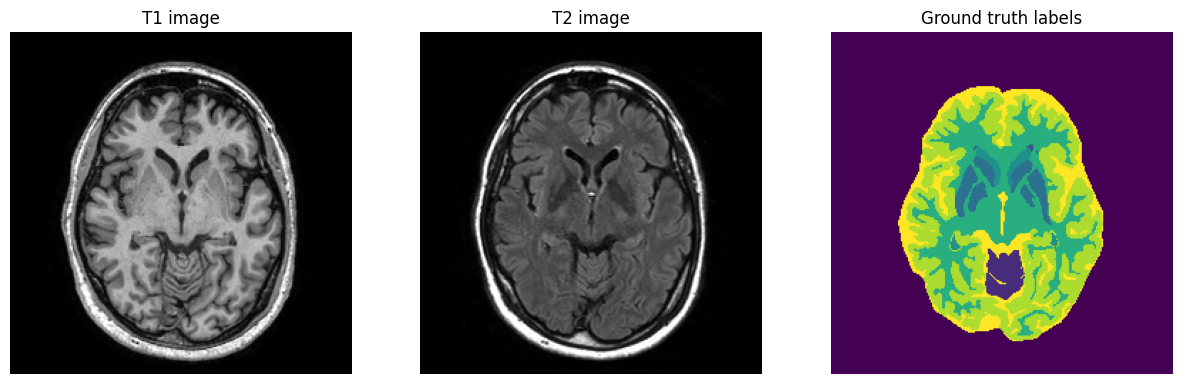

(57600, 8)
(57600, 1)
('T1 intensity', 'T2 intensity', 'Distance to center', 'Smoothed T1 intensity', 'Smoothed T2 intensity', 'T1 edge strength', 'T2 edge strength', 'Local variance')


In [3]:
# Kies subject en slice
image_number = 1
slice_number = 1

X, Y, feature_labels = util.create_dataset(
    image_number=image_number,
    slice_number=slice_number,
    task='tissue'
)

# plot brain images
brains_dir = "../data/dataset_brains/"

t1 = plt.imread(brains_dir + f"{image_number}_{slice_number}_t1.tif")
t2 = plt.imread(brains_dir + f"{image_number}_{slice_number}_t2.tif")
gt = plt.imread(brains_dir + f"{image_number}_{slice_number}_gt.tif")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(t1, cmap="gray")
plt.title("T1 image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(t2, cmap="gray")
plt.title("T2 image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gt)
plt.title("Ground truth labels")
plt.axis("off")

plt.show()

print(X.shape)
print(Y.shape)
print(feature_labels)

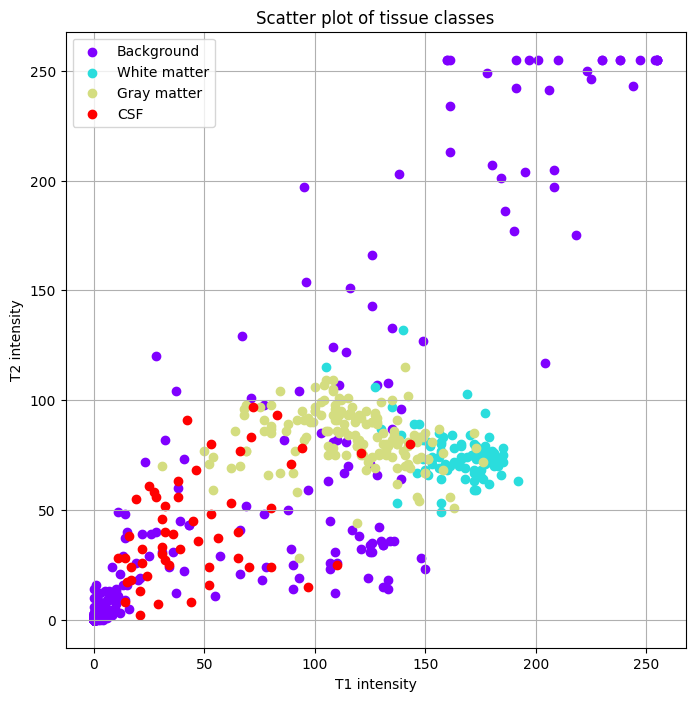

In [4]:
ax = util.scatter_data(X, Y.flatten(), feature0=0, feature1=1)

ax.set_xlabel(feature_labels[0])
ax.set_ylabel(feature_labels[1])
ax.set_title("Scatter plot of tissue classes")

new_labels = [
    "Background",
    "White matter",
    "Gray matter",
    "CSF"
]

handles, old_labels = ax.get_legend_handles_labels()
ax.legend(handles, new_labels)

plt.show()

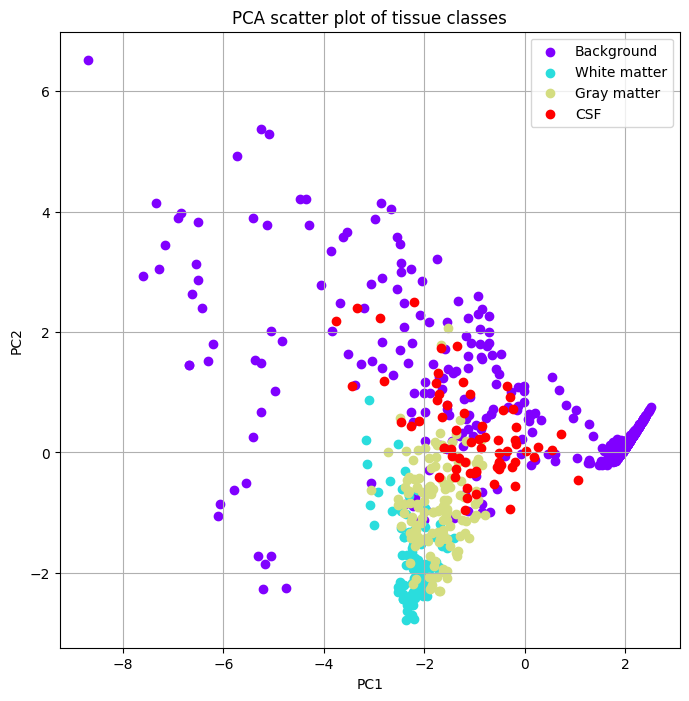

In [5]:
X_norm, _ = seg.normalize_data(X)
X_pca, U, Lambda, fraction_variance = seg.mypca(X_norm)

ax = util.scatter_data(X_pca, Y.flatten(), feature0=0, feature1=1)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA scatter plot of tissue classes")

handles, old_labels = ax.get_legend_handles_labels()
ax.legend(handles, new_labels)

plt.show()

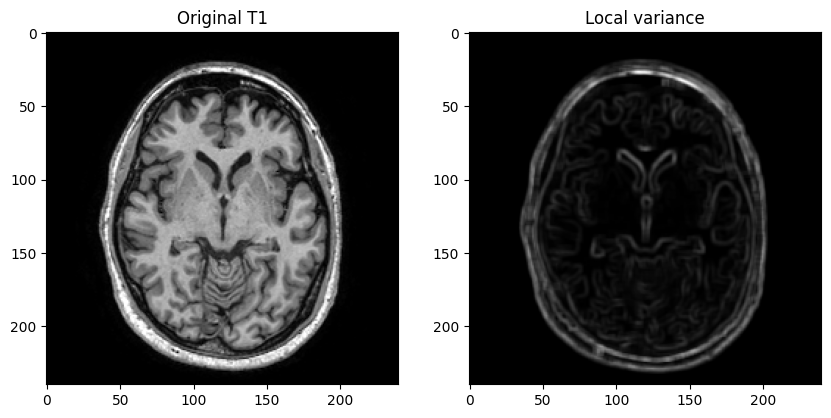

In [6]:
local_var_f, local_var_im = util.extract_myfeatures(t1)

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(t1, cmap='gray')
plt.title('Original T1')

plt.subplot(122)
plt.imshow(local_var_im, cmap='gray')
plt.title('Local variance')
plt.show()

### 2. Model selection and generalization

1. Use the `create_dataset` function to create a training set and a test set for the tissue segmentation task. Use the same slice, but different subjects for training and testing.
2. Use these datasets to investigate using different features and different segmentation methods. You can use both classification error and dice overlap for evaluation, but since now there are four different classes (three tissues and background, you will need to use `dice_multiclass`.
    
    How do you decide what good choices are?  Document this process in a function you create yourself, which returns the best choices given two different subjects.
4. Repeat the above, but use a different subject for testing. Do your conclusions change or stay the same, why? What if you vary the slices? 

In [7]:
import sys
sys.path.append("../code")

import numpy as np
import matplotlib.pyplot as plt
import segmentation as seg
import segmentation_util as util

In [8]:
def evaluate_segmentation_model(train_subject, test_subject, slice_nr, feature_sets, methods, task='tissue'):
    """
    Evaluate different feature combinations and segmentation methods on a
    train-test subject pair.

    For each feature set and segmentation method, a model is trained (if
    applicable) and evaluated on the selected test subject. Performance is
    measured using the classification error and multiclass Dice score. The
    configuration with the highest Dice score is returned as the best result.

    Parameters
    train_subject : int
        Subject used for training.
    test_subject : int
        Subject used for testing.
    slice_nr : int
        Slice number used to create the dataset.
    feature_sets : dict
        Dictionary containing feature set names as keys and lists of feature
        indices as values.
    methods : dict
        Dictionary describing the segmentation methods to evaluate.
        Supported methods are:
        - {"type": "knn", "k": int}
        - {"type": "kmeans", "K": int}
    task : str, optional
        Segmentation task to perform. Default is 'tissue'.

    Returns
    results : list of dict
        List containing the performance metrics for all evaluated
        feature-method combinations.
    best : dict
        Dictionary containing the result with the highest Dice score.
    """

    train_data, train_labels, feature_labels = util.create_dataset(train_subject, slice_nr, task)
    test_data, test_labels, _ = util.create_dataset(test_subject, slice_nr, task)

    results = []

    for feature_name, feature_indices in feature_sets.items():

        X_train = train_data[:, feature_indices]
        X_test = test_data[:, feature_indices]

        for method_name, method_info in methods.items():

            if method_info["type"] == "knn":
                k = method_info["k"]
                pred = seg.segmentation_knn(X_train, train_labels, X_test, k=k)

            elif method_info["type"] == "kmeans":
                K = method_info["K"]
                pred = seg.kmeans_clustering_sklearn(X_test, K=K)

            pred = pred.reshape(-1, 1)

            error = util.classification_error(test_labels, pred)
            dice = util.dice_multiclass(test_labels, pred)

            results.append({
                "train_subject": train_subject,
                "test_subject": test_subject,
                "slice": slice_nr,
                "features": feature_name,
                "method": method_name,
                "error": error,
                "dice": dice
            })

    best = max(results, key=lambda x: x["dice"])

    return results, best

In [22]:
feature_sets = {
    "T1 only": [0],
    "T2 only": [1],
    "T1 + T2": [0, 1],
    "T1 + T2 + coordinate": [0, 1, 2],
    "T1 + T2 + smooth": [0, 1, 3, 4],
    "all features": [0, 1, 2, 3, 4, 5, 6, ]
}

methods = {
    "1-NN": {"type": "knn", "k": 1},
    "3-NN": {"type": "knn", "k": 3},
    "5-NN": {"type": "knn", "k": 5},
    "11-NN": {"type": "knn", "k": 11},
    "15-NN": {"type": "knn", "k": 15},
    "K-means": {"type": "kmeans", "K": 4}
}

In [23]:
results, best = evaluate_segmentation_model(
    train_subject=1,
    test_subject=2,
    slice_nr=1,
    feature_sets=feature_sets,
    methods=methods,
    task='tissue'
)

print("Best choice:")
print(best)

Best choice:
{'train_subject': 1, 'test_subject': 2, 'slice': 1, 'features': 'all features', 'method': '15-NN', 'error': np.float64(0.10756944444444444), 'dice': np.float64(0.7682048356681661)}


In [24]:
for r in results:
    print(
        f"Features: {r['features']:25s} | "
        f"Method: {r['method']:8s} | "
        f"Error: {r['error']:.4f} | "
        f"Dice: {r['dice']:.4f}"
    )

Features: T1 only                   | Method: 1-NN     | Error: 0.2127 | Dice: 0.6046
Features: T1 only                   | Method: 3-NN     | Error: 0.2160 | Dice: 0.5917
Features: T1 only                   | Method: 5-NN     | Error: 0.2095 | Dice: 0.5914
Features: T1 only                   | Method: 11-NN    | Error: 0.2061 | Dice: 0.6097
Features: T1 only                   | Method: 15-NN    | Error: 0.2013 | Dice: 0.6118
Features: T1 only                   | Method: K-means  | Error: 0.2877 | Dice: 0.3986
Features: T2 only                   | Method: 1-NN     | Error: 0.2295 | Dice: 0.5017
Features: T2 only                   | Method: 3-NN     | Error: 0.2229 | Dice: 0.5135
Features: T2 only                   | Method: 5-NN     | Error: 0.2092 | Dice: 0.5126
Features: T2 only                   | Method: 11-NN    | Error: 0.1991 | Dice: 0.5361
Features: T2 only                   | Method: 15-NN    | Error: 0.1900 | Dice: 0.5122
Features: T2 only                   | Method: K-means 

In [12]:
all_tests = []

for test_subject in [2, 3, 4, 5]:
    results, best = evaluate_segmentation_model(
        train_subject=1,
        test_subject=test_subject,
        slice_nr=1,
        feature_sets=feature_sets,
        methods=methods,
        task='tissue'
    )

    all_tests.append(best)

    print(f"\nTest subject {test_subject}")
    print(best)

for slice_nr in [1, 2, 3]:
    results, best = evaluate_segmentation_model(
        train_subject=1,
        test_subject=2,
        slice_nr=slice_nr,
        feature_sets=feature_sets,
        methods=methods,
        task='tissue'
    )

    print(f"\nSlice {slice_nr}")
    print(best)

KeyboardInterrupt: 

## Question 2
To select the best model, different feature combinations and segmentation methods were tested using the same slice but different subjects for training and testing. The performance was evaluated using classification error and multiclass Dice overlap. The best model was chosen as the model with the highest Dice score, because Dice measures overlap between the predicted tissue segmentation and the ground truth.

In general, using both T1 and T2 intensities gives better results than using only one modality. Adding smoothed intensity and spatial coordinate features can improve the segmentation, because these features add spatial and local information. k-NN usually performs better than k-means, because k-NN uses the labelled training data, while k-means is unsupervised.

When changing the test subject or slice, the best settings can change. This is because different subjects and slices can have different tissue shapes, intensities and anatomical structure. Therefore, a good model should perform well over multiple subjects and slices, not only on one test example.

### 3. Combining different methods

1. Try the function `segmentation_combined_knn` on the tissue segmentation task (do not forget to combine the labels - look into e.g. majority voting). 
2. Design a method that combines (some) other methods you have learnt so far in `segmentation_mymethod`. Provide a motivation (based on what you know about the methods) of the choices that you made.
3. The script `segmentation_demo`, creates the results for several methods. This code is a bit slow, so it is not recommended to run it multiple times. (Also, you should not use all of these results to improve your method, since that means you are using the test data as the training data :) ). 
4. Run the script and look at the results. How does your method compare to the individual results? It is not required here that your method is always better! For example, you could select a subject where your method is the best, and a subject where your method is the worst, and explain what is happening in the images.
5. Discuss what other (combinations) methods could be suitable or not suitable for the task and why.

## Question 3
1. In code
2. in `segmentation_mymethod` we made a combination of k-NN classification and K means clustering. With k-NN a supervised method using labelled training data and K means a unsupervised method that combines similiar pixels based on the feature space. With the final predication based on majority voting. By combining this our segmentation is more reliable since it uses more information.
3. In code
4. While looking at the error and Dice score, the results does not differ much. In some cases it is better and some worse. Some difference that are noticeable are in the images itself. In our method there is in most cases less noise visible around the tissue. The reason for this similarity is mainly because our method also uses k-NN and will be voted higher in the majority voting.
5. An other suitable method could be k-NN followed by Markov randomized field (MRF). Since k-NN classifier assigns labels independently to each pixel based only on its feature value, a misclassification may occur. MRF uses spatial information to determine neigbouring pixel labels. This works since tissue regions in MRI are normaly spatially connected. By using different smooting parameters an optimal segmentation can be made

Loading data for 5 subjects...
Finished loading data.
Starting segmentation...


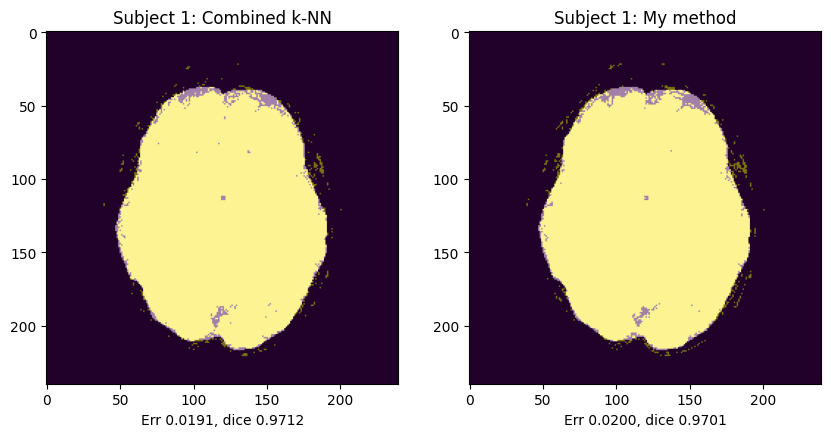

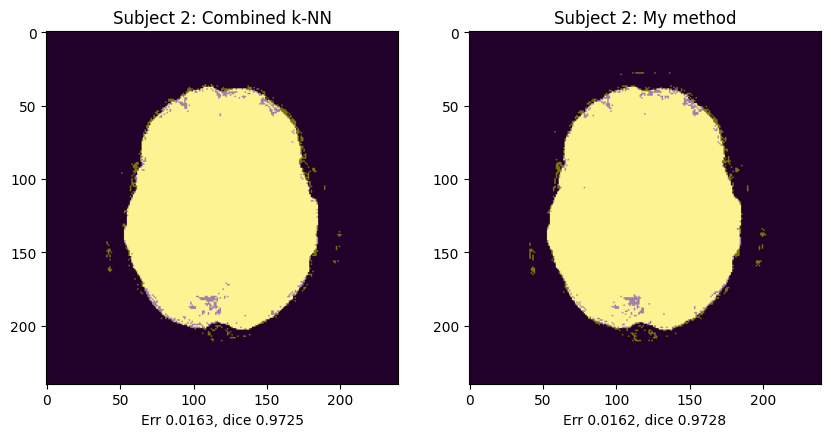

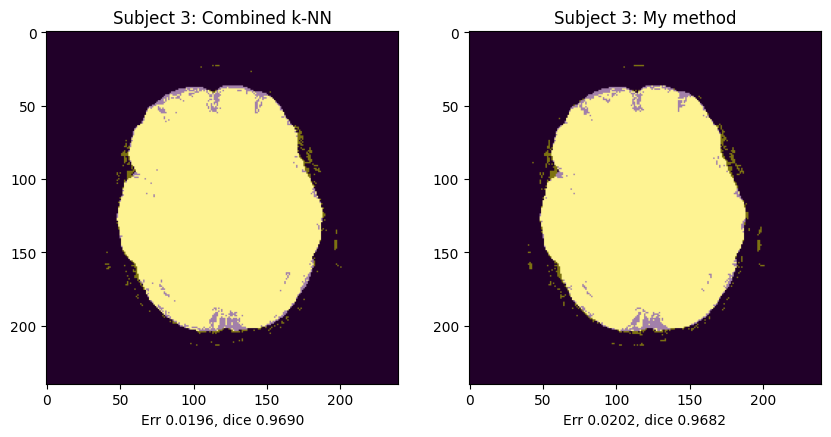

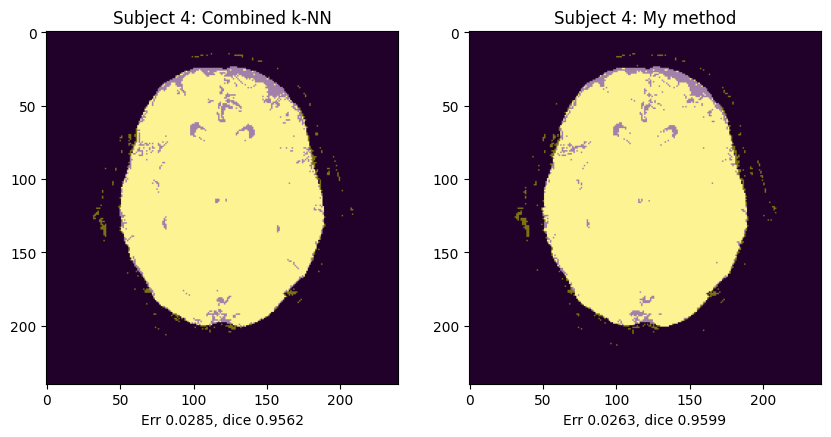

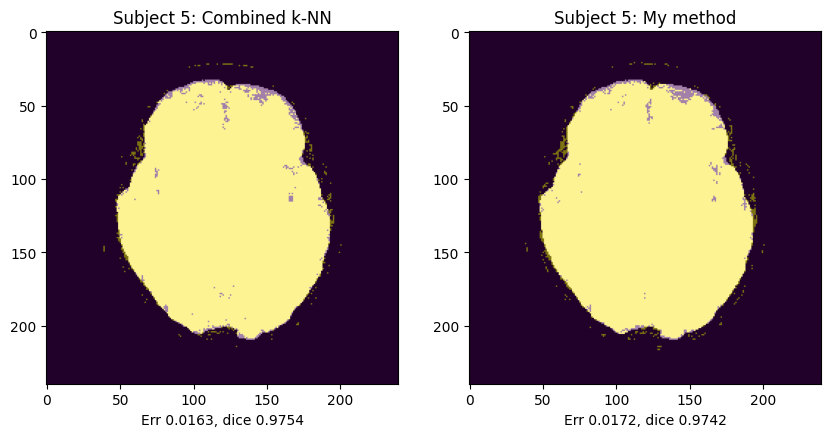

In [1]:
%matplotlib inline
import sys
sys.path.append("../code")
from segmentation_project import segmentation_demo
segmentation_demo()

## Open-ended project work

Define and motivate one research question that you will investigate. This can be a question relating to a method (e.g. what is the impact of X on a particular method) or relating to the problem (e.g. does a specific method fail in specific cases). It can be based on what you have done above or take another direction.
It is recommended to get feedback on your research question from the teaching assistants.

In [2]:
def create_radial_beta_map(image_shape=(240,240), beta_center=0.3, beta_outer=1.5):
    """
    Create a spatially varying beta map based on the distance from the image center.

    The beta value is lowest in the center of the image and increases linearly
    towards the outer edges. This allows the MRF regularization strength to vary
    depending on the pixel location.

    Parameters
    image_shape : tuple of int, optional
        Shape of the image as (rows, cols). Default is (240, 240).
    beta_center : float, optional
        Minimum beta value used at the center of the image. Default is 0.3.
    beta_outer : float, optional
        Maximum beta value used near the outer edge of the image. Default is 1.5.

    Returns
    beta_map : ndarray
        A 2D array with the same shape as the image, containing a beta value for
        each pixel.
    """
    rows, cols = image_shape
    y, x = np.ogrid[:rows, :cols]

    center_r = rows / 2
    center_c = cols / 2

    dist = np.sqrt((y - center_r)**2 + (x - center_c)**2)
    dist = dist / np.max(dist)

    beta_map = beta_center + dist * (beta_outer - beta_center) 

    return beta_map


def mrf_regularization(
        labels,
        image_shape=(240,240),
        n_classes=4,
        beta_center = 0.3, #sterkte van de smoothness term 0 = geen regularisatie, >0 = meer regularisatie
        beta_outer = 1.5,
        n_iter=5): #aantal iteraties van het algoritme, meer iteraties = meer kans op convergentie, maar ook meer rekentijd
                    #verandering van pixel A heeft invloed op pixel B daarom ook meerdere iteraties nodig
    """
    Apply Markov Random Field regularization to a label image.

    This function smooths a pixel-wise label map by iteratively minimizing a local
    energy function. The energy consists of a data term and a smoothness term.
    The data term penalizes changes from the original label, while the smoothness
    term penalizes differences between a pixel and its four direct neighbours.
    The strength of the smoothness term is controlled by a radial beta map.

    Parameters
    labels : ndarray
        Flattened array containing the initial labels for all pixels.
    image_shape : tuple of int, optional
        Shape of the label image as (rows, cols). Default is (240, 240).
    n_classes : int, optional
        Number of possible label classes. Default is 4.
    beta_center : float, optional
        Regularization strength at the center of the image. Default is 0.3.
    beta_outer : float, optional
        Regularization strength near the outer edge of the image. Default is 1.5.
    n_iter : int, optional
        Number of iterations used for the MRF optimization. More iterations can
        improve convergence but increase computation time. Default is 5.

    Returns
    labels_regularized : ndarray
        Flattened array containing the regularized labels.
    """
    
    original = labels.reshape(image_shape)
    current = original.copy()
    beta_map =create_radial_beta_map(image_shape, beta_center=beta_center, beta_outer=beta_outer)
    
    rows, cols = image_shape

    for iteration in range(n_iter):
        for r in range(rows): #ga door alle pixels heen
            for c in range(cols): #ga door alle pixels heen

                best_label = current[r,c] #start met huidige label als beste label, dit is nodig voor het geval dat alle andere labels een hogere energie hebben
                best_energy = np.inf

                for candidate in range(n_classes): #ga door alle mogelijke labels heen, en bereken de energie van elk label, kies het label met de laagste energie als beste label

                    # DATA TERM
                    data_energy = (candidate != original[r,c]) # de data term is 0 als het candidate label gelijk is aan het originele label, en 1 als het candidate label verschillend is van het originele label

                    # SMOOTHNESS TERM
                    smooth_energy = 0

                    if r > 0:
                        smooth_energy += (candidate != current[r-1,c]) #bovenste buurman

                    if r < rows-1:
                        smooth_energy += (candidate != current[r+1,c]) #onderste buurman

                    if c > 0:
                        smooth_energy += (candidate != current[r,c-1]) #linker buurman

                    if c < cols-1:
                        smooth_energy += (candidate != current[r,c+1]) #rechter buurman

                        #we kunnen eventueel ook nog diagonaal buurman meenemen even kijken wat dat doet met de randen. 

                    energy = (data_energy + beta_map[r,c]*smooth_energy)

                    if energy < best_energy:
                        best_energy = energy
                        best_label = candidate

                current[r,c] = best_label

    return current.flatten()

In [4]:
def add_salt_pepper_noise_to_data(data, noise_fraction=0.05):
    """
    Add salt-and-pepper noise to the input feature data.

    A random fraction of pixels is selected. Half of these pixels are assigned
    the minimum feature values, representing pepper noise, and the other half
    are assigned the maximum feature values, representing salt noise.

    Parameters
    data : ndarray
        Input feature array with shape (pixels, features).
    noise_fraction : float, optional
        Fraction of pixels to corrupt with salt-and-pepper noise. Default is 0.05.

    Returns
    noisy_data : ndarray
        Copy of the input data with added salt-and-pepper noise.
    """

    noisy_data = data.copy()

    n_pixels = noisy_data.shape[0]
    n_noisy = int(noise_fraction * n_pixels)

    idx = np.random.choice(n_pixels, n_noisy, replace=False)

    half = n_noisy // 2

    # Per feature de minimale en maximale waarde pakken
    feature_min = np.min(noisy_data, axis=0)
    feature_max = np.max(noisy_data, axis=0)

    # Pepper: lage intensiteit
    noisy_data[idx[:half], :] = feature_min

    # Salt: hoge intensiteit
    noisy_data[idx[half:], :] = feature_max

    return noisy_data


def add_gaussian_noise_to_data(data, noise_fraction=0.15):
    """
    Add Gaussian noise to the input feature data.

    The noise is sampled from a normal distribution with mean zero. The standard
    deviation of the noise is computed per feature and scaled by the given
    noise fraction.

    Parameters
    data : ndarray
        Input feature array with shape (pixels, features).
    noise_fraction : float, optional
        Scaling factor for the noise strength relative to the standard deviation
        of each feature. Default is 0.15.

    Returns
    noisy_data : ndarray
        Copy of the input data with added Gaussian noise.
    """

    noisy_data = data.copy()

    sigma = noise_fraction * np.std(data, axis=0)

    noise = np.random.normal(
        loc=0.0,
        scale=sigma,
        size=data.shape
    )

    noisy_data = noisy_data + noise

    return noisy_data


===== OPEN ENDED PROJECT RESULTS WITH IMAGE NOISE =====

--- Test subject 1 ---
Noisy input Dice=0.7246, Error=0.1422
βc=0.1, βo=0.8 | MRF Dice=0.7523, Error=0.1258
βc=0.2, βo=1.2 | MRF Dice=0.7764, Error=0.1101
βc=0.3, βo=1.5 | MRF Dice=0.7861, Error=0.1054
βc=0.5, βo=2.0 | MRF Dice=0.7831, Error=0.1067
βc=1, βo=1 | MRF Dice=0.7832, Error=0.1083


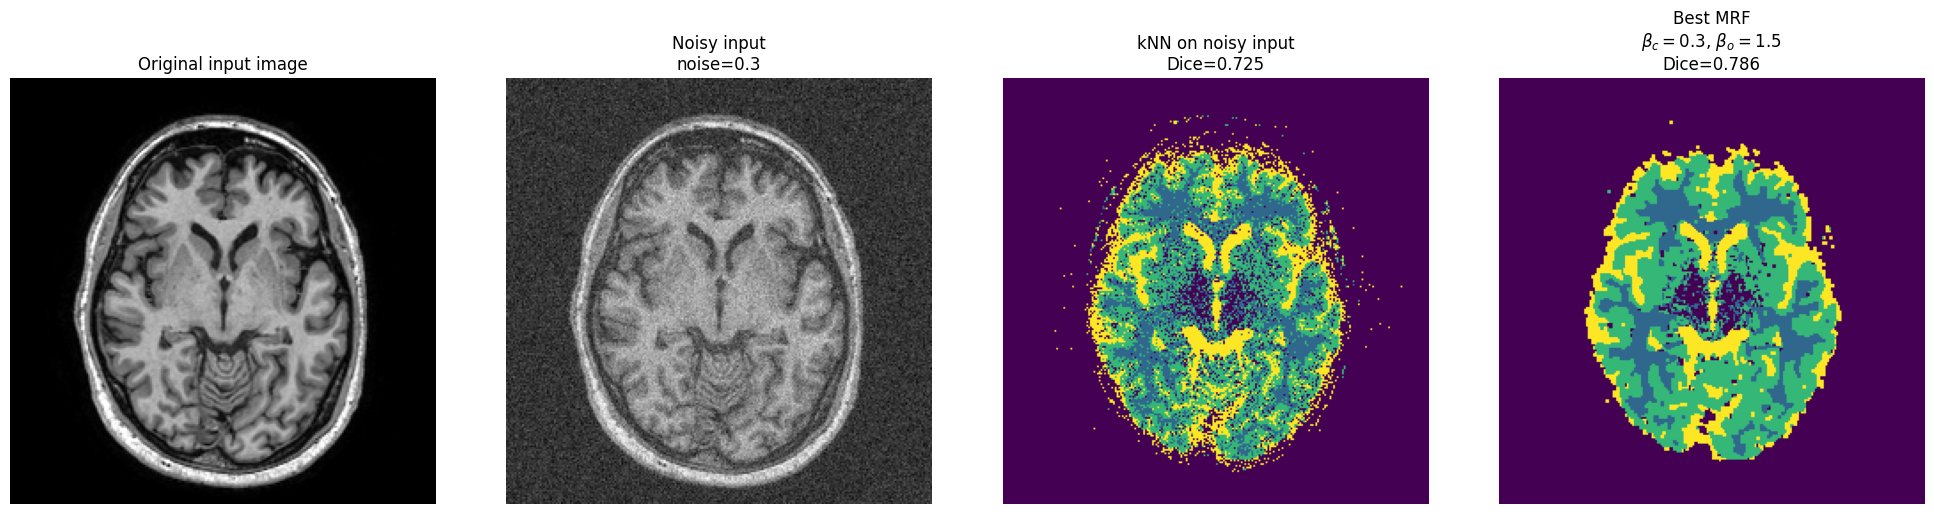


--- Test subject 2 ---
Noisy input Dice=0.7396, Error=0.1230
βc=0.1, βo=0.8 | MRF Dice=0.7625, Error=0.1112
βc=0.2, βo=1.2 | MRF Dice=0.7743, Error=0.1035
βc=0.3, βo=1.5 | MRF Dice=0.7758, Error=0.1027
βc=0.5, βo=2.0 | MRF Dice=0.7761, Error=0.1026
βc=1, βo=1 | MRF Dice=0.7656, Error=0.1065


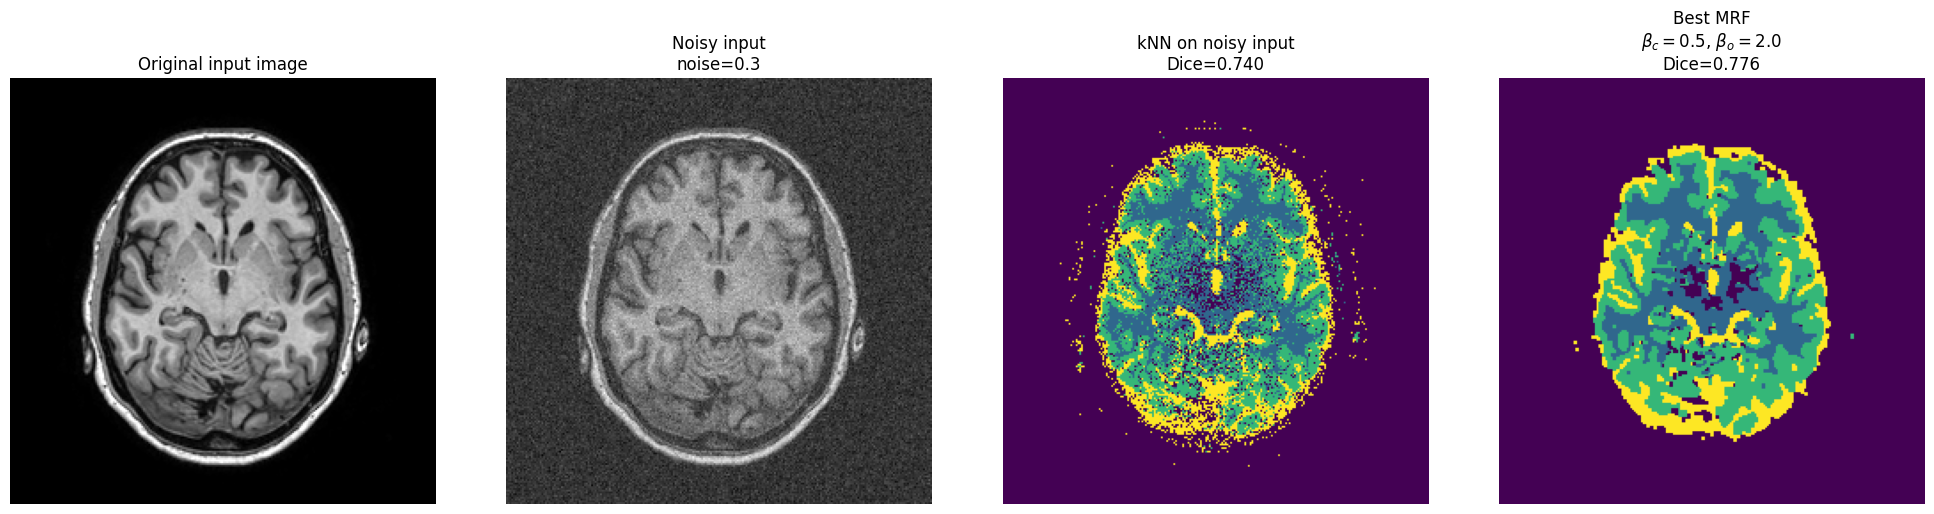


--- Test subject 3 ---
Noisy input Dice=0.6751, Error=0.1667
βc=0.1, βo=0.8 | MRF Dice=0.6923, Error=0.1577
βc=0.2, βo=1.2 | MRF Dice=0.7020, Error=0.1516
βc=0.3, βo=1.5 | MRF Dice=0.7079, Error=0.1494
βc=0.5, βo=2.0 | MRF Dice=0.7010, Error=0.1515
βc=1, βo=1 | MRF Dice=0.6892, Error=0.1556


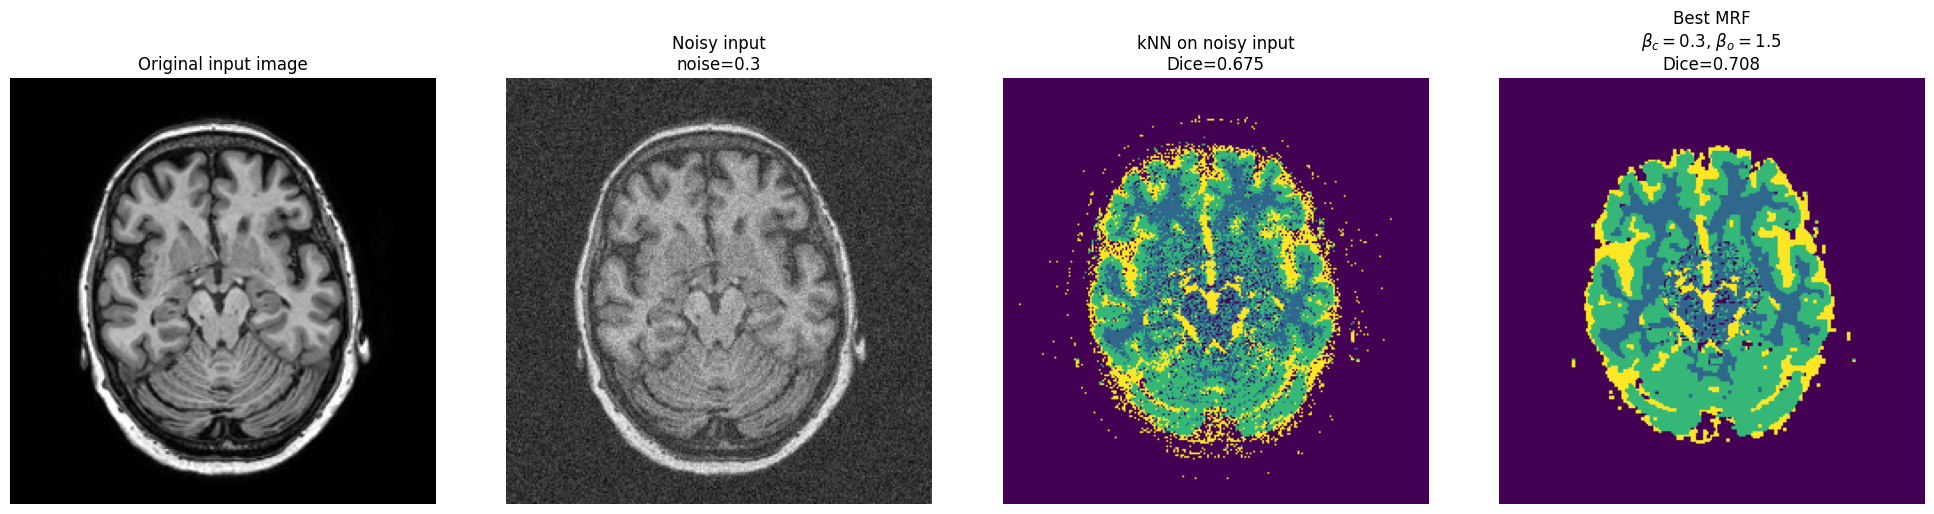


--- Test subject 4 ---
Noisy input Dice=0.7013, Error=0.1532
βc=0.1, βo=0.8 | MRF Dice=0.7140, Error=0.1442
βc=0.2, βo=1.2 | MRF Dice=0.7216, Error=0.1367
βc=0.3, βo=1.5 | MRF Dice=0.7225, Error=0.1361
βc=0.5, βo=2.0 | MRF Dice=0.7215, Error=0.1356
βc=1, βo=1 | MRF Dice=0.7059, Error=0.1430


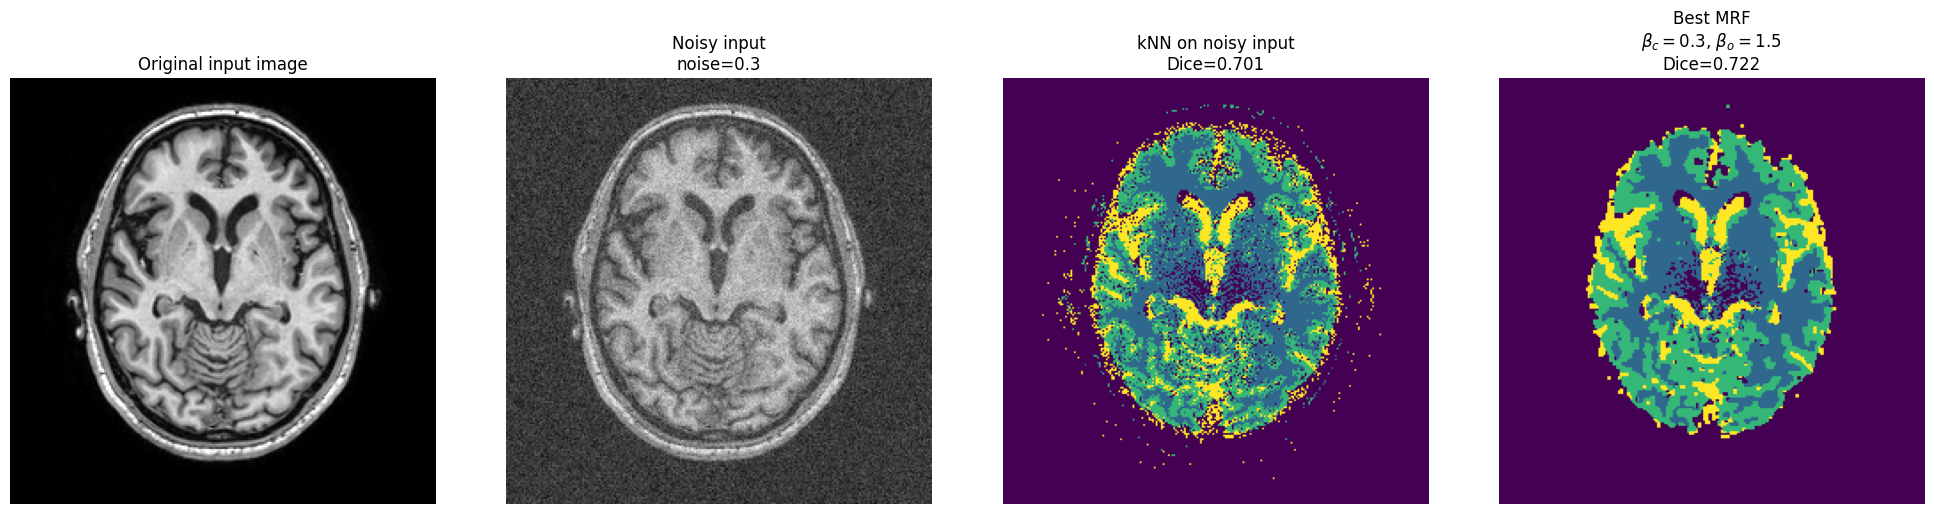


--- Test subject 5 ---
Noisy input Dice=0.6795, Error=0.1589
βc=0.1, βo=0.8 | MRF Dice=0.7043, Error=0.1427
βc=0.2, βo=1.2 | MRF Dice=0.7227, Error=0.1293
βc=0.3, βo=1.5 | MRF Dice=0.7303, Error=0.1260
βc=0.5, βo=2.0 | MRF Dice=0.7259, Error=0.1266
βc=1, βo=1 | MRF Dice=0.7315, Error=0.1253


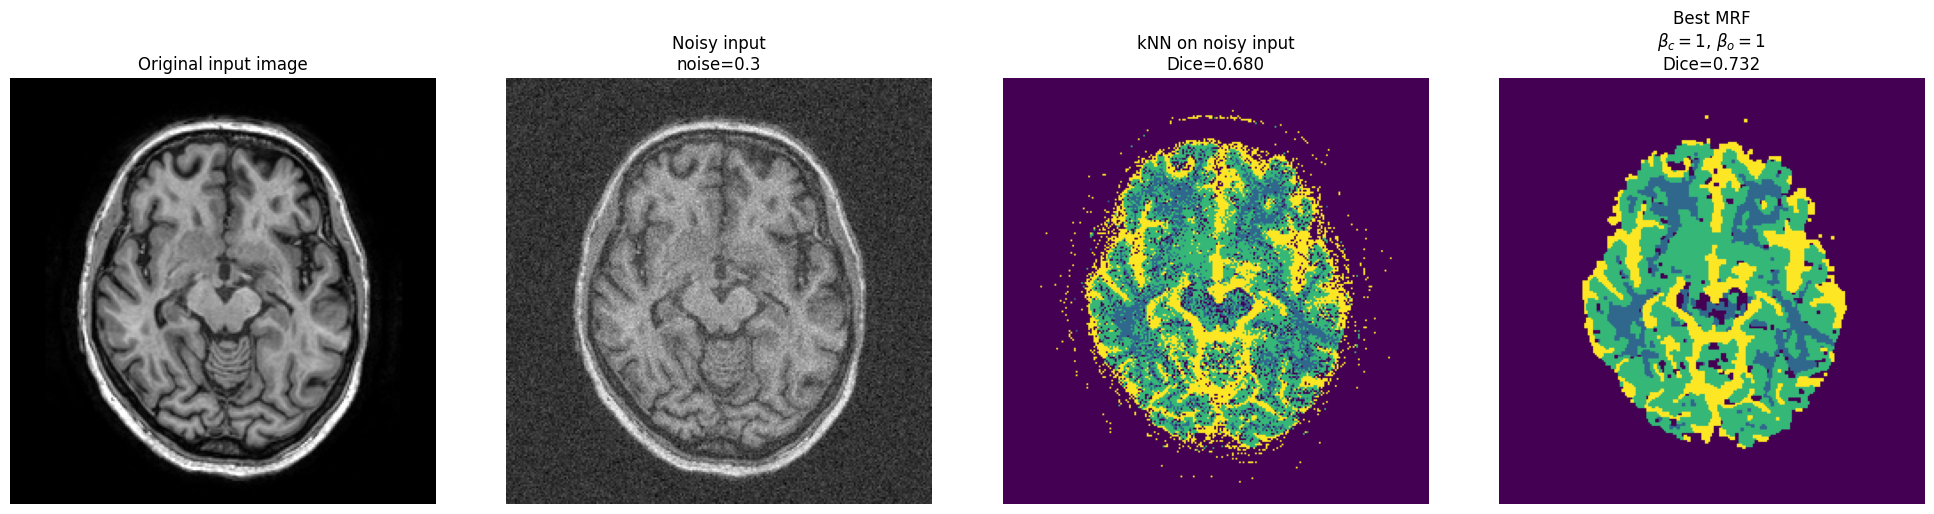


===== MEAN RESULTS PER BETA SETTING =====
βc=0.1, βo=0.8 | kNN Dice=0.7040, MRF Dice=0.7251, kNN Error=0.1488, MRF Error=0.1363
βc=0.2, βo=1.2 | kNN Dice=0.7040, MRF Dice=0.7394, kNN Error=0.1488, MRF Error=0.1262
βc=0.3, βo=1.5 | kNN Dice=0.7040, MRF Dice=0.7445, kNN Error=0.1488, MRF Error=0.1239
βc=0.5, βo=2.0 | kNN Dice=0.7040, MRF Dice=0.7415, kNN Error=0.1488, MRF Error=0.1246
βc=1, βo=1 | kNN Dice=0.7040, MRF Dice=0.7351, kNN Error=0.1488, MRF Error=0.1277

===== BEST AVERAGE SETTING =====
Best setting: βc=0.3, βo=1.5 with mean MRF Dice=0.7445


In [5]:
"""
MAIN code for Open-ended project work
"""

import sys
sys.path.append("../code")

import numpy as np
import matplotlib.pyplot as plt
import segmentation as seg
import segmentation_util as util


# Experiment settings
task = "tissue"
slice_nr = 1
all_subjects = [1, 2, 3, 4, 5]

noise_fraction = 0.3

# Different strengths for the spatially varying MRF regularization
beta_settings = [
    (0.1, 0.8),
    (0.2, 1.2),
    (0.3, 1.5),
    (0.5, 2.0),
    (1, 1)
]

results = []

print("\n===== OPEN ENDED PROJECT RESULTS WITH IMAGE NOISE =====")

for test_subject in all_subjects:

    print(f"\n--- Test subject {test_subject} ---")

    # Load test data for the current subject
    test_data, test_labels, _ = util.create_dataset(test_subject, slice_nr, task)

    # Add noise to the input features before classification
    # test_data_noisy = add_salt_pepper_noise_to_data(
    #     test_data,
    #     noise_fraction=noise_fraction
    # )

    test_data_noisy = add_gaussian_noise_to_data(
        test_data,
        noise_fraction=noise_fraction
    )

    # Use all other subjects as training data
    train_subjects = [s for s in all_subjects if s != test_subject]

    train_data_list = []
    train_labels_list = []

    for train_subject in train_subjects:
        train_data, train_labels, _ = util.create_dataset(train_subject, slice_nr, task)

        train_data_list.append(train_data)
        train_labels_list.append(train_labels)

    train_data_all = np.vstack(train_data_list)
    train_labels_all = np.vstack(train_labels_list)

    # Initial segmentation using kNN on the noisy input data
    pred = seg.segmentation_knn(
        train_data_all,
        train_labels_all,
        test_data_noisy,
        k=15
    )

    # Alternative option: unsupervised k-means clustering
    # pred = seg.kmeans_clustering_sklearn(test_data_noisy, K=4)

    dice_knn = util.dice_multiclass(test_labels, pred)
    err_knn = util.classification_error(test_labels, pred)

    print(f"Noisy input Dice={dice_knn:.4f}, Error={err_knn:.4f}")

    best_dice = -1
    best_error = None
    best_pred = None
    best_beta_c = None
    best_beta_o = None

    # Test different MRF beta settings and keep the best result
    for beta_center, beta_outer in beta_settings:

        pred_mrf = mrf_regularization(
            pred,
            image_shape=(240, 240),
            n_classes=4,
            beta_center=beta_center,
            beta_outer=beta_outer,
            n_iter=5
        )

        dice_mrf = util.dice_multiclass(test_labels, pred_mrf)
        err_mrf = util.classification_error(test_labels, pred_mrf)

        results.append([
            test_subject,
            beta_center,
            beta_outer,
            dice_knn,
            err_knn,
            dice_mrf,
            err_mrf
        ])

        print(
            f"βc={beta_center}, βo={beta_outer} | "
            f"MRF Dice={dice_mrf:.4f}, Error={err_mrf:.4f}"
        )

        if dice_mrf > best_dice:
            best_dice = dice_mrf
            best_error = err_mrf
            best_pred = pred_mrf.copy()
            best_beta_c = beta_center
            best_beta_o = beta_outer

    # Reshape arrays for visual comparison
    ground_truth = test_labels.reshape(240, 240)
    original_img = test_data[:, 0].reshape(240, 240)
    noisy_img = test_data_noisy[:, 0].reshape(240, 240)
    knn_img = pred.reshape(240, 240)
    best_mrf_img = best_pred.reshape(240, 240)

    fig = plt.figure(figsize=(20, 5))

    ax1 = fig.add_subplot(141)
    ax1.imshow(original_img, cmap="gray")
    ax1.set_title("Original input image")
    ax1.axis("off")

    ax2 = fig.add_subplot(142)
    ax2.imshow(noisy_img, cmap="gray")
    ax2.set_title(f"Noisy input\nnoise={noise_fraction}")
    ax2.axis("off")

    ax3 = fig.add_subplot(143)
    ax3.imshow(knn_img)
    ax3.set_title(f"kNN on noisy input\nDice={dice_knn:.3f}")
    ax3.axis("off")

    ax4 = fig.add_subplot(144)
    ax4.imshow(best_mrf_img)
    ax4.set_title(
        rf"Best MRF" "\n"
        rf"$\beta_c={best_beta_c}$, $\beta_o={best_beta_o}$" "\n"
        rf"Dice={best_dice:.3f}"
    )
    ax4.axis("off")

    plt.tight_layout()
    plt.show()


results = np.array(results)

print("\n===== MEAN RESULTS PER BETA SETTING =====")

# Average the results over all test subjects for each beta setting
for beta_center, beta_outer in beta_settings:

    rows = (
        (results[:, 1] == beta_center) &
        (results[:, 2] == beta_outer)
    )

    mean_knn_dice = np.mean(results[rows, 3])
    mean_knn_err = np.mean(results[rows, 4])
    mean_mrf_dice = np.mean(results[rows, 5])
    mean_mrf_err = np.mean(results[rows, 6])

    print(
        f"βc={beta_center}, βo={beta_outer} | "
        f"kNN Dice={mean_knn_dice:.4f}, "
        f"MRF Dice={mean_mrf_dice:.4f}, "
        f"kNN Error={mean_knn_err:.4f}, "
        f"MRF Error={mean_mrf_err:.4f}"
    )


best_mean_dice = -1
best_setting = None

# Find the beta setting with the highest mean MRF Dice score
for beta_center, beta_outer in beta_settings:

    rows = (
        (results[:, 1] == beta_center) &
        (results[:, 2] == beta_outer)
    )

    mean_mrf_dice = np.mean(results[rows, 5])

    if mean_mrf_dice > best_mean_dice:
        best_mean_dice = mean_mrf_dice
        best_setting = (beta_center, beta_outer)

print("\n===== BEST AVERAGE SETTING =====")
print(
    f"Best setting: βc={best_setting[0]}, "
    f"βo={best_setting[1]} "
    f"with mean MRF Dice={best_mean_dice:.4f}"
)